In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



In [2]:
dataset_path = r"C:\Users\komal\Downloads\archive\MY_data\train"   # change this
image_size = (224, 224)


In [3]:
paths = [path.parts[-2:] for path in Path(dataset_path).rglob('*.*')]
df = pd.DataFrame(paths, columns=['Class', 'Images'])
df = df.sort_values('Class')
df.reset_index(drop=True, inplace=True)

print(df.head())
df.tail()

   Class         Images
0  Apple    images.jpeg
1  Apple  img_4251.jpeg
2  Apple  img_4261.jpeg
3  Apple   img_431.jpeg
4  Apple  img_4351.jpeg


,Class,Images
2296,watermelon,img_2891.jpeg
2297,watermelon,img_2921.jpeg
2298,watermelon,img_2971.jpeg
2299,watermelon,img_3021.jpeg
2300,watermelon,img_6451.jpeg


In [4]:
df['image_path'] = df.apply(
    lambda row: os.path.join(dataset_path, row['Class'], row['Images']),
    axis=1
)

df.head()

,Class,Images,image_path
0,Apple,images.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
1,Apple,img_4251.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
2,Apple,img_4261.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
3,Apple,img_431.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
4,Apple,img_4351.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...


In [ ]:
x=df.iloc[:100,:]
x.shape

(100, 3)

In [6]:
x["Class"].value_counts()

Class
Apple    100
Name: count, dtype: int64

In [7]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Class       100 non-null    object
 1   Images      100 non-null    object
 2   image_path  100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB


In [8]:
aug_dir = "augmented_images"
os.makedirs(aug_dir, exist_ok=True)

In [9]:
new_rows = []

for idx, row in x.iterrows():
    img_path = row["image_path"]
    base_class = row["Class"]

    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---- BLUR ----
    blurred = cv2.GaussianBlur(img, (15,15), 0)
    blur_name = f"blur_{idx}.jpg"
    blur_path = os.path.join(aug_dir, blur_name)
    cv2.imwrite(blur_path, blurred)

    new_rows.append({
        "Class": "blur",
        "Images": blur_name,
        "image_path": blur_path
    })

    # ---- FLIP ----
    flipped = cv2.flip(img, 1)
    flip_name = f"flip_{idx}.jpg"
    flip_path = os.path.join(aug_dir, flip_name)
    cv2.imwrite(flip_path, flipped)

    new_rows.append({
        "Class": "flip",
        "Images": flip_name,
        "image_path": flip_path
    })

    # ---- CROP ----
    # cropped = crop_image(img)
    # crop_name = f"crop_{idx}.jpg"
    # crop_path = os.path.join(aug_dir, crop_name)
    # cv2.imwrite(crop_path, cropped)

    # new_rows.append({
    #     "Class": "crop",
    #     "Images": crop_name,
    #     "image_path": crop_path
    # })
    
    # ---- ROTATE ----
    rotated = np.rot90(img)
    rotate_name = f"rotate_{idx}.jpg"
    rotate_path = os.path.join(aug_dir, rotate_name)
    cv2.imwrite(rotate_path, rotated)

    new_rows.append({
        "Class": "rotate",
        "Images": rotate_name,
        "image_path": rotate_path
    })
    
    # ---- RED CHANNEL ----
    red = np.mean(img,axis=2)
    redchannel_name = f"red_{idx}.jpg"
    redchannel_path = os.path.join(aug_dir, redchannel_name)
    cv2.imwrite(redchannel_path, red)

    new_rows.append({
        "Class": "redchannel",
        "Images": redchannel_name,
        "image_path": redchannel_path
    })


In [10]:
aug_df = pd.DataFrame(new_rows)
x = pd.concat([x, aug_df], ignore_index=True)

In [11]:
print(x["Class"].value_counts())
print(x.head())

Class
Apple         100
blur          100
flip          100
rotate        100
redchannel    100
Name: count, dtype: int64
   Class         Images                                         image_path
0  Apple    images.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1  Apple  img_4251.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
2  Apple  img_4261.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
3  Apple   img_431.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
4  Apple  img_4351.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...


In [12]:
x.shape

(500, 3)

In [13]:
x["Class"].value_counts()

Class
Apple         100
blur          100
flip          100
rotate        100
redchannel    100
Name: count, dtype: int64


Class: Apple


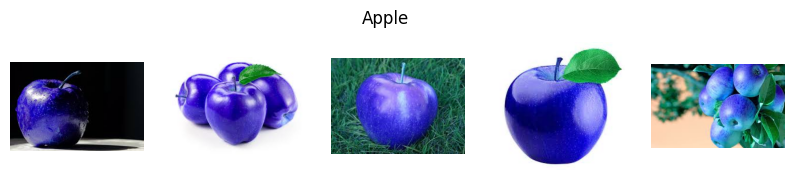


Class: blur


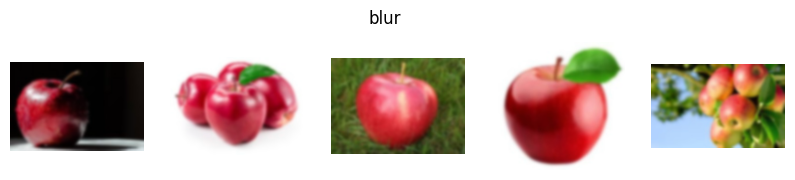


Class: flip


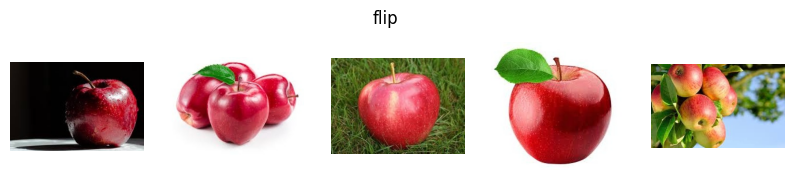


Class: redchannel


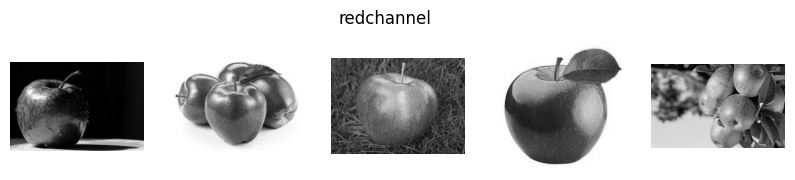


Class: rotate


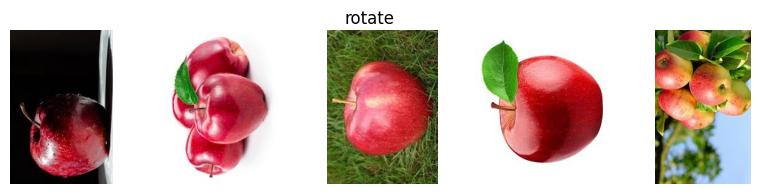

In [14]:
for i,j in x.groupby("Class"):
    print(f"\nClass: {i}")
    
    plt.figure(figsize=(10, 2))
    
    for m,y in enumerate(j["image_path"][:5], start=1):
        img = cv2.imread(y)
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 5, m)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(i)
    plt.show()

In [15]:
print(df.head())
print(df.tail())
print("\nshape:",df.shape)

   Class         Images                                         image_path
0  Apple    images.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1  Apple  img_4251.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
2  Apple  img_4261.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
3  Apple   img_431.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
4  Apple  img_4351.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
           Class         Images  \
2296  watermelon  img_2891.jpeg   
2297  watermelon  img_2921.jpeg   
2298  watermelon  img_2971.jpeg   
2299  watermelon  img_3021.jpeg   
2300  watermelon  img_6451.jpeg   

                                             image_path  
2296  C:\Users\komal\Downloads\archive\MY_data\train...  
2297  C:\Users\komal\Downloads\archive\MY_data\train...  
2298  C:\Users\komal\Downloads\archive\MY_data\train...  
2299  C:\Users\komal\Downloads\archive\MY_data\train...  
2300  C:\Users\komal\Downloads\archive\MY_data\tr


Class: Apple
   Class         Images                                         image_path
0  Apple    images.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1  Apple  img_4251.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
2  Apple  img_4261.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
3  Apple   img_431.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
4  Apple  img_4351.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...


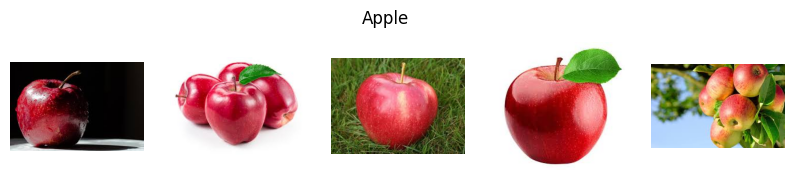


Class: Banana
      Class         Images                                         image_path
230  Banana  img_2561.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
231  Banana  img_2581.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
232  Banana  img_2611.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
233  Banana  img_2701.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
234  Banana  img_2621.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...


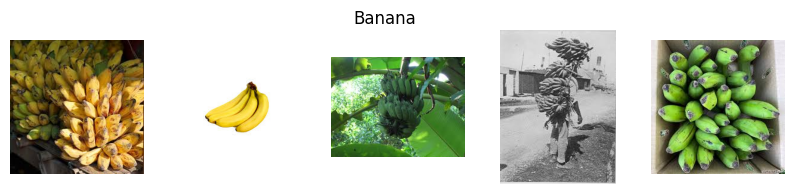


Class: avocado
       Class         Images                                         image_path
460  avocado  img_4611.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
461  avocado  img_2341.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
462  avocado  img_2331.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
463  avocado  img_2321.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
464  avocado  img_2311.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...


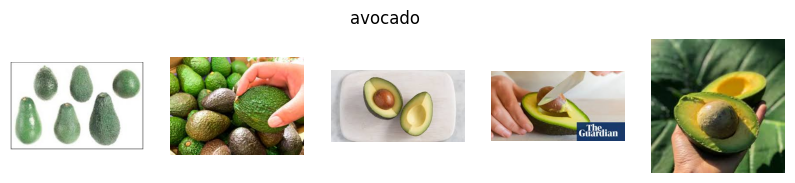


Class: cherry
      Class         Images                                         image_path
690  cherry  img_3241.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
691  cherry  img_3231.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
692  cherry  img_3221.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
693  cherry  img_3541.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
694  cherry  img_3211.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...


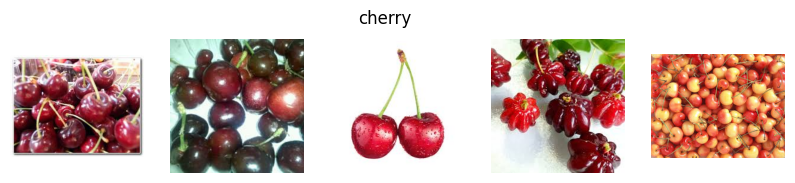


Class: kiwi
    Class         Images                                         image_path
920  kiwi  img_3121.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
921  kiwi  img_3111.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
922  kiwi  img_3101.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
923  kiwi  img_3091.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
924  kiwi  img_3011.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...


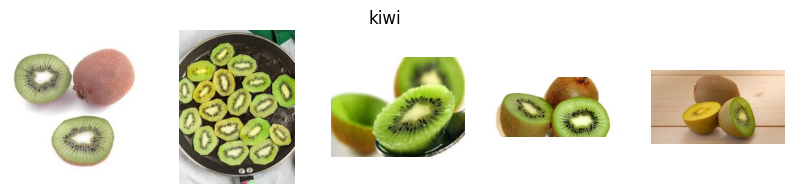


Class: mango
      Class         Images                                         image_path
1150  mango  img_3351.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1151  mango  img_3341.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1152  mango  img_3221.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1153  mango  img_3331.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1154  mango  img_3321.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...


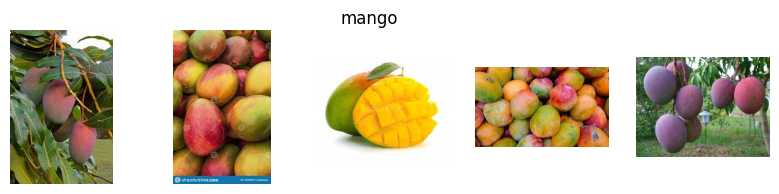


Class: orange
       Class         Images                                         image_path
1381  orange  img_2661.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1382  orange  img_2651.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1383  orange  img_2641.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1384  orange  img_2631.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...
1385  orange  img_2561.jpeg  C:\Users\komal\Downloads\archive\MY_data\train...


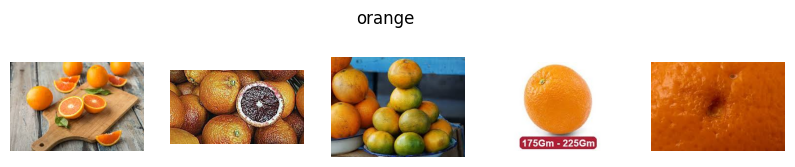


Class: pinenapple
           Class         Images  \
1611  pinenapple   img_341.jpeg   
1612  pinenapple  img_3391.jpeg   
1613  pinenapple  img_3381.jpeg   
1614  pinenapple  img_3361.jpeg   
1615  pinenapple  img_3311.jpeg   

                                             image_path  
1611  C:\Users\komal\Downloads\archive\MY_data\train...  
1612  C:\Users\komal\Downloads\archive\MY_data\train...  
1613  C:\Users\komal\Downloads\archive\MY_data\train...  
1614  C:\Users\komal\Downloads\archive\MY_data\train...  
1615  C:\Users\komal\Downloads\archive\MY_data\train...  


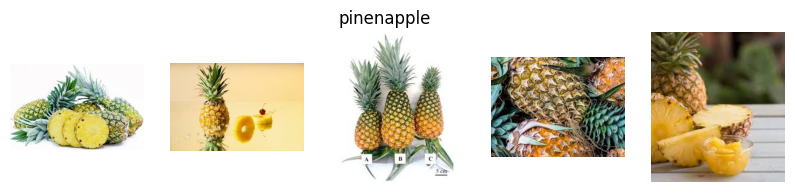


Class: strawberries
             Class         Images  \
1841  strawberries  img_4201.jpeg   
1842  strawberries   img_361.jpeg   
1843  strawberries  img_3621.jpeg   
1844  strawberries   img_371.jpeg   
1845  strawberries   img_381.jpeg   

                                             image_path  
1841  C:\Users\komal\Downloads\archive\MY_data\train...  
1842  C:\Users\komal\Downloads\archive\MY_data\train...  
1843  C:\Users\komal\Downloads\archive\MY_data\train...  
1844  C:\Users\komal\Downloads\archive\MY_data\train...  
1845  C:\Users\komal\Downloads\archive\MY_data\train...  


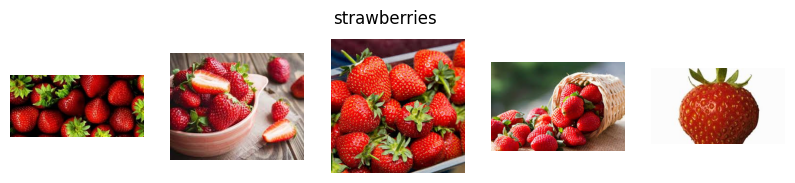


Class: watermelon
           Class         Images  \
2071  watermelon  img_4561.jpeg   
2072  watermelon  img_4601.jpeg   
2073  watermelon  img_4591.jpeg   
2074  watermelon  img_4541.jpeg   
2075  watermelon  img_4431.jpeg   

                                             image_path  
2071  C:\Users\komal\Downloads\archive\MY_data\train...  
2072  C:\Users\komal\Downloads\archive\MY_data\train...  
2073  C:\Users\komal\Downloads\archive\MY_data\train...  
2074  C:\Users\komal\Downloads\archive\MY_data\train...  
2075  C:\Users\komal\Downloads\archive\MY_data\train...  


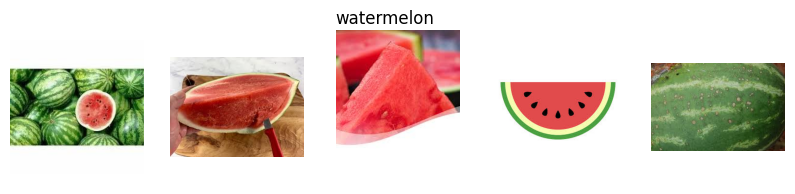

In [16]:
for i,j in df.groupby("Class"):
    print(f"\nClass: {i}")
    print(j.head())
    
    plt.figure(figsize=(10, 2))
    
    for x,y in enumerate(j["image_path"][:5], start=1):
        img = cv2.imread(y)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 5, x)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(i)
    plt.show()

In [17]:
print(df.info(),"\n")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2301 entries, 0 to 2300
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Class       2301 non-null   object
 1   Images      2301 non-null   object
 2   image_path  2301 non-null   object
dtypes: object(3)
memory usage: 54.1+ KB
None 



,Class,Images,image_path
count,2301,2301,2301
unique,10,588,2301
top,mango,img_2181.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
freq,231,10,1


In [18]:
df.describe()

,Class,Images,image_path
count,2301,2301,2301
unique,10,588,2301
top,mango,img_2181.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
freq,231,10,1


In [19]:
df["Class"].value_counts()

Class
mango           231
Apple           230
Banana          230
avocado         230
cherry          230
kiwi            230
orange          230
pinenapple      230
strawberries    230
watermelon      230
Name: count, dtype: int64

In [20]:
print(df.isnull().sum())

Class         0
Images        0
image_path    0
dtype: int64


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["Images"].duplicated().sum()

np.int64(1713)

In [23]:
df[df["Images"].duplicated(keep=False)]

,Class,Images,image_path
1,Apple,img_4251.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
2,Apple,img_4261.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
3,Apple,img_431.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
4,Apple,img_4351.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
5,Apple,img_441.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
...,...,...,...
2295,watermelon,img_2881.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
2296,watermelon,img_2891.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
2297,watermelon,img_2921.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...
2298,watermelon,img_2971.jpeg,C:\Users\komal\Downloads\archive\MY_data\train...


In [24]:
df.drop(df[df["Images"].duplicated(keep=False)].index, inplace=True)

In [25]:
df["Images"].duplicated().sum()

np.int64(0)

In [26]:
df["Class"].unique()

array(['Apple', 'Banana', 'avocado', 'cherry', 'kiwi', 'mango', 'orange',
       'pinenapple', 'strawberries', 'watermelon'], dtype=object)